# Layout Detection Benchmark
**3 Models × 3 Datasets — Fully Self-Contained Kaggle Benchmark**

This notebook runs end-to-end evaluation of three layout detection models (DocLayoutYOLO, Nemotron-Parse-v1.1, LandingAI ADE DPT-2) against three open-source layout datasets (DocLayNet, PubLayNet, DocBank) over a sampled set of 30 pages per dataset. All bounding boxes and class labels are normalized to a common canonical layout taxonomy before metrics are computed.

### Models under Evaluation:
- **DocLayoutYOLO**: Fast, CPU-capable layout detector from the `docling` package.
- **NVIDIA Nemotron-Parse-v1.1**: Encoder-decoder VLM for document parsing (requires CUDA GPU).
- **LandingAI ADE DPT-2**: Client-based parser (requires a `LANDING_AI_KEY` in Kaggle Secrets).

### Datasets:
- **DocLayNet**: COCO format layout dataset (11 classes).
- **PubLayNet**: COCO format layout dataset (5 classes).
- **DocBank**: Token-level TSV layout dataset (aggregated to block-level bounding boxes, 9 classes).

Enable GPU in notebook settings before running.


In [1]:
# Skipped pip install to use venv environment packages

In [2]:
# CELL 2: Config & seeds
import os
import random
import numpy as np
import torch
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import json
from IPython.display import display
warnings.filterwarnings('ignore')

SEED       = 42
N_SAMPLES  = 3    # pages per dataset
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_DIR = '/kaggle/working/benchmark_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cache paths (as requested in EDIT 1)
DATASET_CACHE_DIR = '/kaggle/working/cache/datasets'
PRED_CACHE_DIR    = '/kaggle/working/cache/predictions'
os.makedirs(DATASET_CACHE_DIR, exist_ok=True)
os.makedirs(PRED_CACHE_DIR,    exist_ok=True)

# Sub-dirs per dataset
for ds in ['DocLayNet', 'PubLayNet', 'DocBank']:
    os.makedirs(os.path.join(DATASET_CACHE_DIR, ds, 'images'), exist_ok=True)

# Read LandingAI key from Kaggle Secrets if available
try:
    from kaggle_secrets import UserSecretsClient
    LANDING_AI_KEY = UserSecretsClient().get_secret("LANDING_AI_KEY")
except Exception:
    LANDING_AI_KEY = "Y3FhOWdseDZjNTc0OHd4ZDhiOTExOnB6N3MzZkpRd1B1NEJhZFkyMUNBT3V4TTlvaE91TkY5"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

In [3]:
# CELL 2b: Cache status cell
def cache_exists(dataset_name):
    meta_path = f'{DATASET_CACHE_DIR}/{dataset_name}/meta.json'
    gt_path   = f'{DATASET_CACHE_DIR}/{dataset_name}/gt.json'
    img_dir   = f'{DATASET_CACHE_DIR}/{dataset_name}/images'
    if not (os.path.exists(meta_path) and os.path.exists(gt_path)):
        return False
    pngs = [f for f in os.listdir(img_dir) if f.endswith('.png')]
    return len(pngs) >= N_SAMPLES

def pred_cache_path(model_name, dataset_name):
    safe = model_name.replace('/', '_').replace('-', '_')
    return f'{PRED_CACHE_DIR}/{safe}__{dataset_name}.json'

def pred_cache_exists(model_name, dataset_name):
    return os.path.exists(pred_cache_path(model_name, dataset_name))

print('═' * 55)
print('  CACHE STATUS')
print('═' * 55)
for ds in ['DocLayNet', 'PubLayNet', 'DocBank']:
    ds_hit = cache_exists(ds)
    print(f'  Dataset  {ds:12s}: {"✅ CACHED" if ds_hit else "⬇️  WILL DOWNLOAD"}')

print()
for model in ['DocLayoutYOLO', 'Nemotron', 'ADE-DPT2']:
    for ds in ['DocLayNet', 'PubLayNet', 'DocBank']:
        hit = pred_cache_exists(model, ds)
        if hit:
            print(f'  Preds    {model:15s} × {ds:12s}: ✅ CACHED')
        else:
            print(f'  Preds    {model:15s} × {ds:12s}: '
                  f'{"⏭️  SKIP (no key)" if model=="ADE-DPT2" and not LANDING_AI_KEY else "🔄 WILL RUN"}')
print('═' * 55)


═══════════════════════════════════════════════════════
  CACHE STATUS
═══════════════════════════════════════════════════════
  Dataset  DocLayNet   : ✅ CACHED
  Dataset  PubLayNet   : ✅ CACHED
  Dataset  DocBank     : ✅ CACHED

  Preds    DocLayoutYOLO   × DocLayNet   : ✅ CACHED
  Preds    DocLayoutYOLO   × PubLayNet   : ✅ CACHED
  Preds    DocLayoutYOLO   × DocBank     : ✅ CACHED
  Preds    Nemotron        × DocLayNet   : ✅ CACHED
  Preds    Nemotron        × PubLayNet   : ✅ CACHED
  Preds    Nemotron        × DocBank     : ✅ CACHED
  Preds    ADE-DPT2        × DocLayNet   : ✅ CACHED
  Preds    ADE-DPT2        × PubLayNet   : ✅ CACHED
  Preds    ADE-DPT2        × DocBank     : ✅ CACHED
═══════════════════════════════════════════════════════


In [4]:
# CELL 3: Dataset loading & sampling
import json
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset
import numpy as np

CANONICAL = {
  'title', 'text', 'table', 'picture',
  'list_item', 'caption', 'section_header',
  'page_footer', 'page_header', 'formula', 'footnote'
}

DOCLAYNET_TO_CANONICAL = {
  'Caption': 'caption', 'Footnote': 'footnote', 'Formula': 'formula',
  'List-item': 'list_item', 'Page-footer': 'page_footer',
  'Page-header': 'page_header', 'Picture': 'picture',
  'Section-header': 'section_header', 'Table': 'table',
  'Text': 'text', 'Title': 'title'
}

PUBLAYNET_TO_CANONICAL = {
  'text': 'text', 'title': 'title', 'list': 'list_item',
  'figure': 'picture', 'table': 'table'
}

DOCBANK_TO_CANONICAL = {
  'abstract': 'text', 'author': 'text', 'caption': 'caption',
  'equation': 'formula', 'figure': 'picture', 'footer': 'page_footer',
  'list': 'list_item', 'paragraph': 'text', 'reference': 'text',
  'section': 'section_header', 'table': 'table', 'title': 'title'
}

DLN_CAT_NAMES = {
    1: 'Caption', 2: 'Footnote', 3: 'Formula', 4: 'List-item',
    5: 'Page-footer', 6: 'Page-header', 7: 'Picture',
    8: 'Section-header', 9: 'Table', 10: 'Text', 11: 'Title'
}

PLN_CAT_NAMES = {1: 'text', 2: 'title', 3: 'list', 4: 'table', 5: 'figure'}

DOCBANK_INT_TO_STR = {
    0: 'abstract', 1: 'author', 2: 'caption', 3: 'equation',
    4: 'figure', 5: 'footer', 6: 'list', 7: 'paragraph',
    8: 'reference', 9: 'section', 10: 'table', 11: 'title'
}

VALID_CLASSES_PER_DATASET = {
    'DocLayNet': {'caption', 'footnote', 'formula', 'list_item', 'page_footer',
                  'page_header', 'picture', 'section_header', 'table', 'text', 'title'},
    'PubLayNet': {'text', 'title', 'list_item', 'picture', 'table'},
    'DocBank': {'text', 'caption', 'formula', 'picture', 'page_footer',
                'list_item', 'section_header', 'table', 'title'}
}

def make_serializable(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, list):
        return [make_serializable(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): make_serializable(v) for k, v in obj.items()}
    return obj

def _parse_coco_annos(annos, cat_names, label_map):
    gt_boxes = []
    if isinstance(annos, dict):
        n = len(annos.get('bbox', []))
        for i in range(n):
            bbox = annos['bbox'][i]
            cat_id = annos.get('category_id', annos.get('category', [0]))[i]
            cat_name = cat_names.get(cat_id)
            if not cat_name:
                cat_name = cat_names.get(cat_id + 1, 'text')
            canonical = label_map.get(cat_name, None)
            if canonical:
                x, y, w, h = bbox
                gt_boxes.append({'bbox': [x, y, x + w, y + h], 'label': canonical})
    elif isinstance(annos, list):
        for ann in annos:
            bbox = ann['bbox']
            cat_id = ann.get('category_id', ann.get('category', 0))
            cat_name = cat_names.get(cat_id)
            if not cat_name:
                cat_name = cat_names.get(cat_id + 1, 'text')
            canonical = label_map.get(cat_name, None)
            if canonical:
                x, y, w, h = bbox
                gt_boxes.append({'bbox': [x, y, x + w, y + h], 'label': canonical})
    return gt_boxes

def coco_to_canonical_doclaynet(row):
    gt_boxes = []
    if 'objects' in row and row['objects']:
        objs = row['objects']
        if isinstance(objs, dict):
            bboxes = objs.get('bbox', [])
            cat_ids = objs.get('category_id', [])
            for bbox, cat_id in zip(bboxes, cat_ids):
                cat_name = DLN_CAT_NAMES.get(cat_id + 1, 'Text')
                canonical = DOCLAYNET_TO_CANONICAL.get(cat_name)
                if canonical:
                    x, y, w, h = bbox
                    gt_boxes.append({'bbox': [x, y, x + w, y + h], 'label': canonical})
        elif isinstance(objs, list):
            for obj in objs:
                bbox = obj['bbox']
                cat_id = obj['category_id']
                cat_name = DLN_CAT_NAMES.get(cat_id + 1, 'Text')
                canonical = DOCLAYNET_TO_CANONICAL.get(cat_name)
                if canonical:
                    x, y, w, h = bbox
                    gt_boxes.append({'bbox': [x, y, x + w, y + h], 'label': canonical})
    return gt_boxes

def coco_to_canonical_publaynet(row):
    gt_boxes = []
    if 'bboxes' in row and 'categories' in row:
        bboxes = row['bboxes']
        categories = row['categories']
        for bbox, cat_id in zip(bboxes, categories):
            cat_name = PLN_CAT_NAMES.get(cat_id)
            if not cat_name:
                cat_name = PLN_CAT_NAMES.get(cat_id + 1, 'text')
            canonical = PUBLAYNET_TO_CANONICAL.get(cat_name)
            if canonical:
                x, y, w, h = bbox
                gt_boxes.append({'bbox': [x, y, x + w, y + h], 'label': canonical})
    elif 'annotations' in row:
        gt_boxes = _parse_coco_annos(row['annotations'], PLN_CAT_NAMES, PUBLAYNET_TO_CANONICAL)
    elif 'objects' in row:
        gt_boxes = _parse_coco_annos(row['objects'], PLN_CAT_NAMES, PUBLAYNET_TO_CANONICAL)
    return gt_boxes

def reconstruct_docbank_image(row):
    if 'pagesize' in row:
        pw, ph = row['pagesize']
    else:
        pw, ph = 612, 792
    return Image.new('RGB', (int(pw), int(ph)), 'white')

def save_dataset_cache(dataset_name, sampled_images, sampled_gt, sample_indices):
    img_dir = f'{DATASET_CACHE_DIR}/{dataset_name}/images'
    for i, img in enumerate(sampled_images):
        img.save(f'{img_dir}/sample_{i:03d}.png')
    with open(f'{DATASET_CACHE_DIR}/{dataset_name}/gt.json', 'w') as f:
        json.dump(make_serializable(sampled_gt), f)
    with open(f'{DATASET_CACHE_DIR}/{dataset_name}/meta.json', 'w') as f:
        json.dump({'seed': SEED, 'n_samples': N_SAMPLES, 'indices': sample_indices}, f)
    print(f'  ✅ Cached {dataset_name} → {img_dir}')

def load_dataset_cache(dataset_name):
    img_dir = f'{DATASET_CACHE_DIR}/{dataset_name}/images'
    with open(f'{DATASET_CACHE_DIR}/{dataset_name}/gt.json') as f:
        sampled_gt = json.load(f)
    sampled_images = [
        Image.open(f'{img_dir}/sample_{i:03d}.png').convert('RGB')
        for i in range(N_SAMPLES)
    ]
    print(f'  ✅ Loaded {dataset_name} from cache ({N_SAMPLES} pages)')
    return sampled_images, sampled_gt

# Check cache or download
import ast
import itertools
from datasets import Image as HFImage

samples = {}
for dataset_name in ['DocLayNet', 'PubLayNet', 'DocBank']:
    print(f'\n[{dataset_name}]')
    if cache_exists(dataset_name):
        images, gt = load_dataset_cache(dataset_name)
    else:
        print(f'  Cache miss — downloading from HuggingFace...')
        if dataset_name == 'DocLayNet':
            # Strategy: Stream ds4sd/DocLayNet split test. HF Hub automatically converts to Parquet format.
            raw = load_dataset("ds4sd/DocLayNet", split="test", streaming=True, trust_remote_code=True)
            raw = raw.cast_column("image", HFImage())
            raw = raw.shuffle(seed=SEED, buffer_size=100)
            sampled_iter = itertools.islice(raw, N_SAMPLES)
            indices = list(range(N_SAMPLES))
            images, gt = [], []
            for row in tqdm(sampled_iter, total=N_SAMPLES, desc='DocLayNet'):
                img     = row['image'].convert('RGB')
                gt_boxes = coco_to_canonical_doclaynet(row)
                images.append(img)
                gt.append(gt_boxes)
                
        elif dataset_name == 'PubLayNet':
            # Strategy: Stream shunk031/PubLayNet split validation. Avoid decode_rle=False (Parquet handles natively).
            raw = load_dataset("shunk031/PubLayNet", split="validation", streaming=True, trust_remote_code=True)
            raw = raw.cast_column("image", HFImage())
            raw = raw.shuffle(seed=SEED, buffer_size=100)
            sampled_iter = itertools.islice(raw, N_SAMPLES)
            indices = list(range(N_SAMPLES))
            images, gt = [], []
            for row in tqdm(sampled_iter, total=N_SAMPLES, desc='PubLayNet'):
                img     = row['image'].convert('RGB')
                gt_boxes = coco_to_canonical_publaynet(row)
                images.append(img)
                gt.append(gt_boxes)
                
        elif dataset_name == 'DocBank':
            # Strategy: Stream maveriq/DocBank split test since liminghao1630/DocBank raw zip files do not support streaming.
            # Do NOT shuffle to ensure order matches test.jsonl exactly
            raw = load_dataset("maveriq/DocBank", split="test", streaming=True)
            raw = raw.cast_column("image", HFImage())
            sampled_iter = itertools.islice(raw, N_SAMPLES)
            
            # Paths to test.jsonl and gt_coco.json
            test_jsonl_path = r"C:\Users\user\.cache\huggingface\hub\datasets--maveriq--DocBank\snapshots\5df3e3504e161a0fac9c3f3c9aba26cc22e3dc63\test.jsonl"
            gt_coco_path = r"C:\kaggle\working\cache\datasets\DocBank\gt_coco.json"
            
            basenames = []
            with open(test_jsonl_path, 'r', encoding='utf-8') as f:
                for idx, line in enumerate(f):
                    if idx >= N_SAMPLES:
                        break
                    _, basename = eval(line.strip())
                    basenames.append(basename)
                    
            with open(gt_coco_path, 'r', encoding='utf-8') as f:
                gt_coco_data = json.load(f)
                
            indices = list(range(N_SAMPLES))
            images, gt = [], []
            for i, row in enumerate(tqdm(sampled_iter, total=N_SAMPLES, desc='DocBank')):
                img = row['image'].convert('RGB')
                
                # Retrieve ground truth annotations using basename mapping
                basename = basenames[i] if i < len(basenames) else ""
                gt_boxes = gt_coco_data.get(basename, [])
                
                images.append(img)
                gt.append(gt_boxes)
                
        save_dataset_cache(dataset_name, images, gt, indices)
    
    samples[dataset_name] = [
        {'image': img, 'gt': gt_boxes}
        for img, gt_boxes in zip(images, gt)
    ]



[DocLayNet]
  ✅ Loaded DocLayNet from cache (3 pages)

[PubLayNet]
  ✅ Loaded PubLayNet from cache (3 pages)

[DocBank]
  ✅ Loaded DocBank from cache (3 pages)


In [5]:
# CELL 4: Inference — DocLayoutYOLO
def save_pred_cache(model_name, dataset_name, preds):
    with open(pred_cache_path(model_name, dataset_name), 'w') as f:
        json.dump(make_serializable(preds), f)
    print(f'  ✅ Predictions cached: {model_name} on {dataset_name}')

def load_pred_cache(model_name, dataset_name):
    with open(pred_cache_path(model_name, dataset_name)) as f:
        raw = json.load(f)
    preds = {int(k): v for k, v in raw.items()}
    print(f'  ✅ Loaded predictions from cache: {model_name} on {dataset_name}')
    return preds

from docling.document_converter import DocumentConverter
from docling.datamodel.base_models import InputFormat
import tempfile
import img2pdf

try:
    converter = DocumentConverter(allowed_formats=[InputFormat.IMAGE])
except Exception:
    converter = DocumentConverter()

def run_doclayolo(pil_image):
    preds = []
    tmp_path = None
    try:
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
            pil_image.convert('RGB').save(tmp.name, format='PNG')
            tmp_path = tmp.name
        
        try:
            result = converter.convert(tmp_path)
        except Exception as e:
            print(f'  ⚠️ Direct image conversion failed: {e}')
            return []
            
        doc = result.document
        img_w, img_h = pil_image.size
        
        scale_x, scale_y = 1.0, 1.0
        if hasattr(doc, 'pages') and doc.pages:
            for pk, pv in doc.pages.items():
                pw = pv.size.width if hasattr(pv.size, 'width') else img_w
                ph = pv.size.height if hasattr(pv.size, 'height') else img_h
                scale_x = img_w / pw if pw > 0 else 1
                scale_y = img_h / ph if ph > 0 else 1
                break
                
        norm_map = {
            'sectionheader': 'section_header',
            'list': 'list_item',
            'pageheader': 'page_header',
            'pagefooter': 'page_footer',
        }
                
        for item_tuple in (doc.iterate_items() if hasattr(doc, 'iterate_items') else []):
            element = item_tuple[0] if isinstance(item_tuple, tuple) else item_tuple
            label_raw = type(element).__name__.lower().replace('item', '').replace('docling', '')
            mapped_label = norm_map.get(label_raw, label_raw)
            
            canonical = None
            for k, v in DOCLAYNET_TO_CANONICAL.items():
                if k.lower().replace('-', '_') == mapped_label or k.lower() == mapped_label:
                    canonical = v
                    break
                    
            if not canonical:
                continue
            if hasattr(element, 'prov') and element.prov:
                bbox = element.prov[0].bbox
                x0 = bbox.l * scale_x
                y0_raw = img_h - (bbox.t * scale_y)
                x1 = bbox.r * scale_x
                y1_raw = img_h - (bbox.b * scale_y)
                y0, y1 = min(y0_raw, y1_raw), max(y0_raw, y1_raw)
                if (x1 - x0) * (y1 - y0) > 50:
                    preds.append({'bbox': [x0, y0, x1, y1], 'label': canonical, 'score': 0.9})
    except Exception as e:
        print(f'  ⚠️ Page failed: {e}')
    finally:
        if tmp_path and os.path.exists(tmp_path):
            os.unlink(tmp_path)
    return preds
dl_preds = {}
for dataset_name in ['DocLayNet', 'PubLayNet', 'DocBank']:
    print(f'\n[DocLayoutYOLO × {dataset_name}]')
    if pred_cache_exists('DocLayoutYOLO', dataset_name):
        dl_preds[dataset_name] = load_pred_cache('DocLayoutYOLO', dataset_name)
    else:
        print('  Running inference...')
        preds = {}
        for i, sample in enumerate(tqdm(samples[dataset_name], desc=dataset_name)):
            try:
                preds[i] = run_doclayolo(sample['image'])
            except Exception as e:
                print(f'  ⚠️ Page {i} failed: {e}')
                preds[i] = []
        dl_preds[dataset_name] = preds
        save_pred_cache('DocLayoutYOLO', dataset_name, preds)



[DocLayoutYOLO × DocLayNet]
  ✅ Loaded predictions from cache: DocLayoutYOLO on DocLayNet

[DocLayoutYOLO × PubLayNet]
  ✅ Loaded predictions from cache: DocLayoutYOLO on PubLayNet

[DocLayoutYOLO × DocBank]
  ✅ Loaded predictions from cache: DocLayoutYOLO on DocBank


In [6]:
# CELL 5: Inference — NVIDIA Nemotron-Parse-v1.1
nm_preds = {}
PROC_W, PROC_H = 1024, 832
import re

nemo_model = None
nemo_processor = None
nemo_tokenizer = None
nemo_gen_config = None

def load_nemo():
    global nemo_model, nemo_processor, nemo_tokenizer, nemo_gen_config
    if nemo_model is None:
        print("Loading Nemotron-Parse-v1.1 (this takes ~35s)...")
        from transformers import AutoModel, AutoProcessor, AutoTokenizer, GenerationConfig
        MODEL_PATH = "nvidia/NVIDIA-Nemotron-Parse-v1.1"
        nemo_model = AutoModel.from_pretrained(
            MODEL_PATH, trust_remote_code=True,
            torch_dtype=torch.float16, low_cpu_mem_usage=True
        ).to(DEVICE).eval()
        
        # Load processor & tokenizer with use_fast=True
        nemo_processor = AutoProcessor.from_pretrained(MODEL_PATH, trust_remote_code=True, use_fast=True)
        
        # Apply the VRAM optimization: configure the processor for 1024x832 target resolution
        nemo_processor.image_processor.final_size = (PROC_W, PROC_H)
        nemo_processor.image_processor._create_transforms()
        
        nemo_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True)
        nemo_gen_config = GenerationConfig.from_pretrained(MODEL_PATH)
        nemo_gen_config.max_new_tokens = 512

BLOCK_PATTERN = re.compile(
    r'<x_([0-9.]+)><y_([0-9.]+)>(.*?)'
    r'<x_([0-9.]+)><y_([0-9.]+)><class_([^>]+)>',
    re.DOTALL)
    
TASK_PROMPT = '</s><s><predict_bbox><predict_classes>'

def run_nemotron(pil_image):
    orig_w, orig_h = pil_image.size
    # Image padding matches target width and height
    padded = Image.new('RGB', (PROC_H, PROC_W), (255, 255, 255))
    
    # We maintain aspect ratio relative to (PROC_H, PROC_W)
    if orig_w > PROC_H or orig_h > PROC_W:
        scale = min(PROC_H / orig_w, PROC_W / orig_h)
        new_w, new_h = int(orig_w * scale), int(orig_h * scale)
        resized = pil_image.resize((new_w, new_h), Image.LANCZOS)
        pad_x = (PROC_H - new_w) // 2
        pad_y = (PROC_W - new_h) // 2
        padded.paste(resized, (pad_x, pad_y))
        effective_scale = scale
    else:
        pad_x = (PROC_H - orig_w) // 2
        pad_y = (PROC_W - orig_h) // 2
        padded.paste(pil_image, (pad_x, pad_y))
        effective_scale = 1.0
        
    inputs = nemo_processor(images=padded, text=TASK_PROMPT,
                           return_tensors='pt', add_special_tokens=False).to(DEVICE)
                           
    try:
        with torch.no_grad(), torch.cuda.amp.autocast():
            outputs = nemo_model.generate(**inputs, generation_config=nemo_gen_config,
                                         max_new_tokens=512)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        with torch.no_grad(), torch.cuda.amp.autocast():
            outputs = nemo_model.generate(**inputs, generation_config=nemo_gen_config,
                                         max_new_tokens=256)
    
    decoded = nemo_tokenizer.decode(outputs[0], skip_special_tokens=False)
    del inputs, outputs
    torch.cuda.empty_cache()
    
    detections = []
    for m in BLOCK_PATTERN.finditer(decoded):
        x0_n, y0_n = float(m.group(1)), float(m.group(2))
        x1_n, y1_n = float(m.group(4)), float(m.group(5))
        cls = m.group(6).strip()
        
        # Coordinates map back using target sizes
        x0_px = x0_n * PROC_H - pad_x
        y0_px = y0_n * PROC_W - pad_y
        x1_px = x1_n * PROC_H - pad_x
        y1_px = y1_n * PROC_W - pad_y
        
        if effective_scale != 1.0:
            x0_px /= effective_scale; y0_px /= effective_scale
            x1_px /= effective_scale; y1_px /= effective_scale
            
        x0_px = max(0, min(orig_w, x0_px))
        y0_px = max(0, min(orig_h, y0_px))
        x1_px = max(0, min(orig_w, x1_px))
        y1_px = max(0, min(orig_h, y1_px))
        
        canonical = DOCLAYNET_TO_CANONICAL.get(cls, DOCLAYNET_TO_CANONICAL.get(cls.lower()))
        if canonical and (x1_px - x0_px) > 1 and (y1_px - y0_px) > 1:
            detections.append({'bbox': [x0_px, y0_px, x1_px, y1_px],
                               'label': canonical, 'score': 0.85})
    return detections

for dataset_name in ['DocLayNet', 'PubLayNet', 'DocBank']:
    print(f'\n[Nemotron × {dataset_name}]')
    if pred_cache_exists('Nemotron', dataset_name):
        nm_preds[dataset_name] = load_pred_cache('Nemotron', dataset_name)
    else:
        if DEVICE == 'cuda':
            load_nemo()
            preds = {}
            for i, sample in enumerate(tqdm(samples[dataset_name], desc=dataset_name)):
                try:
                    preds[i] = run_nemotron(sample['image'])
                except Exception as e:
                    print(f'  ⚠️ Page {i} failed: {e}')
                    preds[i] = []
            nm_preds[dataset_name] = preds
            save_pred_cache('Nemotron', dataset_name, preds)
        else:
            print("⚠️ CUDA GPU is not available. Nemotron-Parse cannot run. Filling with empty predictions.")
            nm_preds[dataset_name] = {i: [] for i in range(N_SAMPLES)}
            save_pred_cache('Nemotron', dataset_name, nm_preds[dataset_name])

if nemo_model is not None:
    del nemo_model, nemo_processor, nemo_tokenizer
    torch.cuda.empty_cache()



[Nemotron × DocLayNet]
  ✅ Loaded predictions from cache: Nemotron on DocLayNet

[Nemotron × PubLayNet]
  ✅ Loaded predictions from cache: Nemotron on PubLayNet

[Nemotron × DocBank]
  ✅ Loaded predictions from cache: Nemotron on DocBank


In [7]:
# CELL 6: Inference — LandingAI ADE DPT-2
ade_preds = {}
ADE_TO_CANONICAL = {
  'text': 'text', 'table': 'table', 'figure': 'picture',
  'logo': 'picture', 'barcode': 'picture', 'attestation': 'text'
}

ade_cache_hit = all(pred_cache_exists('ADE-DPT2', ds) for ds in ['DocLayNet', 'PubLayNet', 'DocBank'])

if ade_cache_hit:
    for dataset_name in ['DocLayNet', 'PubLayNet', 'DocBank']:
        ade_preds[dataset_name] = load_pred_cache('ADE-DPT2', dataset_name)
elif LANDING_AI_KEY:
    from pathlib import Path
    from landingai_ade import LandingAIADE
    client = LandingAIADE(apikey=LANDING_AI_KEY)
    
    def run_ade(pil_image):
        preds = []
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
            pil_image.save(tmp.name)
            tmp_path = tmp.name
        try:
            response = client.parse(document=Path(tmp_path), model="dpt-2-20260410")
            img_w, img_h = pil_image.size
            for chunk in (response.chunks if hasattr(response, 'chunks') else []):
                chunk_type = chunk.type if hasattr(chunk, 'type') else 'text'
                if chunk_type == 'marginalia':
                    if hasattr(chunk, 'grounding') and hasattr(chunk.grounding, 'box'):
                        y_center = (chunk.grounding.box.top + chunk.grounding.box.bottom) / 2
                        canonical = 'page_header' if y_center < img_h * 0.15 else 'page_footer'
                    else:
                        canonical = 'page_footer'
                else:
                    canonical = ADE_TO_CANONICAL.get(chunk_type)
                if canonical and hasattr(chunk, 'grounding') and hasattr(chunk.grounding, 'box'):
                    b = chunk.grounding.box
                    preds.append({'bbox': [b.left * img_w, b.top * img_h, b.right * img_w, b.bottom * img_h],
                                  'label': canonical, 'score': 0.8})
        except Exception as e:
            print(f"  ⚠️ ADE error: {e}")
        finally:
            if os.path.exists(tmp_path):
                os.unlink(tmp_path)
        return preds

    for dataset_name in ['DocLayNet', 'PubLayNet', 'DocBank']:
        print(f'\n[ADE-DPT2 × {dataset_name}]')
        preds = {}
        for i, sample in enumerate(tqdm(samples[dataset_name], desc=dataset_name)):
            try:
                preds[i] = run_ade(sample['image'])
            except Exception as e:
                print(f'  ⚠️ Page {i} failed: {e}')
                preds[i] = []
        ade_preds[dataset_name] = preds
        save_pred_cache('ADE-DPT2', dataset_name, preds)
else:
    print("⚠️ Skipping ADE DPT-2 inference (no LANDING_AI_KEY provided). Filling with empty predictions.")
    for dataset_name in ['DocLayNet', 'PubLayNet', 'DocBank']:
        ade_preds[dataset_name] = {i: [] for i in range(N_SAMPLES)}
        save_pred_cache('ADE-DPT2', dataset_name, ade_preds[dataset_name])


  ✅ Loaded predictions from cache: ADE-DPT2 on DocLayNet
  ✅ Loaded predictions from cache: ADE-DPT2 on PubLayNet
  ✅ Loaded predictions from cache: ADE-DPT2 on DocBank


In [8]:
# CELL 7: Evaluation functions
from collections import defaultdict

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return inter / (areaA + areaB - inter)

def match_predictions(gt_boxes, pred_boxes, iou_threshold=0.5):
    candidates = []
    for gi, gt in enumerate(gt_boxes):
        for pi, pred in enumerate(pred_boxes):
            if gt['label'] == pred['label']:
                iou = compute_iou(gt['bbox'], pred['bbox'])
                if iou >= iou_threshold:
                    candidates.append((iou, gi, pi))
    candidates.sort(key=lambda x: -x[0])

    used_gt, used_pred, matched = set(), set(), []
    for iou, gi, pi in candidates:
        if gi not in used_gt and pi not in used_pred:
            matched.append((gi, pi, iou))
            used_gt.add(gi); used_pred.add(pi)

    unmatched_gt = [i for i in range(len(gt_boxes)) if i not in used_gt]
    unmatched_pred = [i for i in range(len(pred_boxes)) if i not in used_pred]
    return matched, unmatched_gt, unmatched_pred

def compute_ap(precisions, recalls):
    if not precisions or not recalls:
        return 0.0
    ap = 0.0
    for t in np.arange(0.0, 1.1, 0.1):
        p_gt_t = [p for p, r in zip(precisions, recalls) if r >= t]
        if p_gt_t:
            ap += max(p_gt_t)
    return ap / 11.0

def run_cocoeval(all_gt, all_preds, valid_classes):
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
    import tempfile
    import json
    
    class_to_id = {cls: idx + 1 for idx, cls in enumerate(sorted(list(valid_classes)))}
    categories = [{'id': idx, 'name': name} for name, idx in class_to_id.items()]
    
    gt_coco = {'images': [], 'annotations': [], 'categories': categories}
    pred_coco = []
    
    ann_id = 1
    for img_idx, (gt_boxes, pred_boxes) in enumerate(zip(all_gt, all_preds)):
        gt_f = [b for b in gt_boxes if b['label'] in valid_classes]
        pr_f = [b for b in pred_boxes if b['label'] in valid_classes]
        
        # Dynamically lookup image size from samples cache to support pixel-coordinate evaluation
        ds_name = None
        for ds, cls_set in VALID_CLASSES_PER_DATASET.items():
            if cls_set == valid_classes:
                ds_name = ds
                break
        
        img_w, img_h = 1000, 1000
        if ds_name and ds_name in samples and img_idx < len(samples[ds_name]):
            img_w, img_h = samples[ds_name][img_idx]['image'].size
            
        gt_coco['images'].append({'id': img_idx, 'width': img_w, 'height': img_h})
        
        for b in gt_f:
            x0, y0, x1, y1 = b['bbox']
            w, h = max(0, x1 - x0), max(0, y1 - y0)
            gt_coco['annotations'].append({
                'id': ann_id, 'image_id': img_idx,
                'category_id': class_to_id[b['label']],
                'bbox': [x0, y0, w, h], 'area': w * h, 'iscrowd': 0
            })
            ann_id += 1
            
        for b in pr_f:
            x0, y0, x1, y1 = b['bbox']
            w, h = max(0, x1 - x0), max(0, y1 - y0)
            pred_coco.append({
                'image_id': img_idx, 'category_id': class_to_id[b['label']],
                'bbox': [x0, y0, w, h], 'score': b.get('score', 0.9), 'area': w * h
            })
            
    if not gt_coco['annotations']:
        return None
        
    with tempfile.NamedTemporaryFile(suffix='.json', mode='w', delete=False) as f_gt:
        json.dump(gt_coco, f_gt)
        gt_path = f_gt.name
        
    if not pred_coco:
        os.unlink(gt_path)
        return {'mAP50': 0.0, 'mAP5095': 0.0}
        
    with tempfile.NamedTemporaryFile(suffix='.json', mode='w', delete=False) as f_pred:
        json.dump(pred_coco, f_pred)
        pred_path = f_pred.name
        
    try:
        import io, sys
        stdout = sys.stdout
        sys.stdout = io.StringIO()
        
        coco_gt = COCO(gt_path)
        coco_dt = coco_gt.loadRes(pred_path)
        coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
        coco_eval.params.catIds = list(class_to_id.values())
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        
        sys.stdout = stdout
        ap5095 = max(0.0, coco_eval.stats[0])
        ap50 = max(0.0, coco_eval.stats[1])
    except Exception as e:
        print(f"COCOeval failed: {e}. Falling back to manual AP.")
        ap50, ap5095 = None, None
    finally:
        if os.path.exists(gt_path): os.unlink(gt_path)
        if os.path.exists(pred_path): os.unlink(pred_path)
        
    if ap50 is not None:
        return {'mAP50': ap50, 'mAP5095': ap5095}
    return None

def compute_map(all_gt, all_preds, iou_thresholds, valid_classes):
    ap50_per_class = {}
    
    # 1. Class-specific AP@50 (manual 11-point calculation)
    for cls in valid_classes:
        cls_gts_count = sum(1 for gt_boxes in all_gt for b in gt_boxes if b['label'] == cls)
        
        if cls_gts_count == 0:
            ap50_per_class[cls] = 0.0
            continue
            
        tp_flags = []
        scores = []
        
        for page_idx, (gt_boxes, pred_boxes) in enumerate(zip(all_gt, all_preds)):
            gt_f = [b for b in gt_boxes if b['label'] == cls]
            pr_f = [b for b in pred_boxes if b['label'] == cls]
            pr_sorted = sorted(pr_f, key=lambda x: x.get('score', 0.9), reverse=True)
            
            used_gt = set()
            for p_box in pr_sorted:
                best_iou = 0.0
                best_gi = -1
                for gi, g_box in enumerate(gt_f):
                    if gi not in used_gt:
                        iou = compute_iou(g_box['bbox'], p_box['bbox'])
                        if iou > best_iou:
                            best_iou = iou
                            best_gi = gi
                if best_iou >= 0.5:
                    tp_flags.append(1)
                    used_gt.add(best_gi)
                else:
                    tp_flags.append(0)
                scores.append(p_box.get('score', 0.9))
                
        if not scores:
            ap50_per_class[cls] = 0.0
            continue
            
        sorted_indices = np.argsort(scores)[::-1]
        tp_flags = [tp_flags[i] for i in sorted_indices]
        
        tp_cumsum = np.cumsum(tp_flags)
        fp_cumsum = np.cumsum([1 - x for x in tp_flags])
        
        precisions = []
        recalls = []
        for tp_sum, fp_sum in zip(tp_cumsum, fp_cumsum):
            precisions.append(tp_sum / (tp_sum + fp_sum))
            recalls.append(tp_sum / cls_gts_count)
            
        ap50_per_class[cls] = compute_ap(precisions, recalls)

    # 2. Grid of thresholds for F1 and manual mAPs
    ap_per_thr = []
    for iou_thr in iou_thresholds:
        class_f1s = []
        for cls in valid_classes:
            tp_all = 0; fp_all = 0; fn_all = 0
            for gt_boxes, pred_boxes in zip(all_gt, all_preds):
                gt_f = [b for b in gt_boxes if b['label'] == cls]
                pr_f = [b for b in pred_boxes if b['label'] == cls]
                matched, ugt, upr = match_predictions(gt_f, pr_f, iou_thr)
                tp_all += len(matched)
                fn_all += len(ugt)
                fp_all += len(upr)
            p = tp_all / (tp_all + fp_all) if (tp_all + fp_all) else 0
            r = tp_all / (tp_all + fn_all) if (tp_all + fn_all) else 0
            f1_cls = 2 * p * r / (p + r) if (p + r) else 0
            class_f1s.append(f1_cls)
        ap_per_thr.append(np.mean(class_f1s) if class_f1s else 0)

    # 3. Overall Precision, Recall, F1, mean IoU at threshold 0.50
    tp_total = 0; fp_total = 0; fn_total = 0; all_ious = []
    for gt_boxes, pred_boxes in zip(all_gt, all_preds):
        gt_f = [b for b in gt_boxes if b['label'] in valid_classes]
        pr_f = [b for b in pred_boxes if b['label'] in valid_classes]
        matched, ugt, upr = match_predictions(gt_f, pr_f, 0.5)
        tp_total += len(matched)
        fn_total += len(ugt)
        fp_total += len(upr)
        for _, _, iou in matched:
            all_ious.append(iou)
            
    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    mean_iou = np.mean(all_ious) if all_ious else 0.0

    manual_ap50 = np.mean(list(ap50_per_class.values())) if ap50_per_class else 0.0
    manual_ap5095 = np.mean(ap_per_thr) if ap_per_thr else 0.0
    
    coco_metrics = None
    try:
        coco_metrics = run_cocoeval(all_gt, all_preds, valid_classes)
    except Exception as e:
        print(f"COCOeval execution warning: {e}")
        
    if coco_metrics is not None:
        mAP50 = coco_metrics['mAP50']
        mAP5095 = coco_metrics['mAP5095']
    else:
        mAP50 = manual_ap50
        mAP5095 = manual_ap5095
        
    return {
        'mAP50': mAP50,
        'mAP5095': mAP5095,
        'precision': precision,
        'recall': recall,
        'F1': f1,
        'mean_iou': mean_iou,
        'ap50_per_class': ap50_per_class
    }


In [9]:
# CELL 8: Run evaluation
results = {}
for dataset_name in ['DocLayNet', 'PubLayNet', 'DocBank']:
    results[dataset_name] = {}
    gt_list = [s['gt'] for s in samples[dataset_name]]
    valid_cls = VALID_CLASSES_PER_DATASET[dataset_name]

    print(f"\nEvaluating: {dataset_name}...")
    for model_name, pred_dict in [
        ('DocLayoutYOLO', dl_preds[dataset_name]),
        ('Nemotron',      nm_preds[dataset_name]),
        ('ADE-DPT2',      ade_preds[dataset_name]),
    ]:
        pred_list = [pred_dict[i] for i in range(N_SAMPLES)]
        metrics = compute_map(gt_list, pred_list,
                              iou_thresholds=[0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95],
                              valid_classes=valid_cls)
        results[dataset_name][model_name] = metrics
        print(f"  {dataset_name} | {model_name}: "
              f"mAP@50={metrics['mAP50']:.3f}  "
              f"mAP@50:95={metrics['mAP5095']:.3f}  "
              f"F1={metrics['F1']:.3f}")



Evaluating: DocLayNet...
  DocLayNet | DocLayoutYOLO: mAP@50=0.436  mAP@50:95=0.352  F1=0.571
  DocLayNet | Nemotron: mAP@50=0.439  mAP@50:95=0.304  F1=0.674
  DocLayNet | ADE-DPT2: mAP@50=0.242  mAP@50:95=0.144  F1=0.414

Evaluating: PubLayNet...
  PubLayNet | DocLayoutYOLO: mAP@50=0.545  mAP@50:95=0.412  F1=0.738
  PubLayNet | Nemotron: mAP@50=0.383  mAP@50:95=0.224  F1=0.692
  PubLayNet | ADE-DPT2: mAP@50=0.490  mAP@50:95=0.275  F1=0.642

Evaluating: DocBank...
  DocBank | DocLayoutYOLO: mAP@50=0.016  mAP@50:95=0.007  F1=0.206
  DocBank | Nemotron: mAP@50=0.015  mAP@50:95=0.005  F1=0.187
  DocBank | ADE-DPT2: mAP@50=0.023  mAP@50:95=0.008  F1=0.237


In [10]:
# CELL 9: 3×3 Summary Table
import pandas as pd
from IPython.display import display

rows = []
for ds in ['DocLayNet', 'PubLayNet', 'DocBank']:
    row = {'Dataset': ds,
           'GT_Classes': len(VALID_CLASSES_PER_DATASET[ds]),
           'N_Pages': N_SAMPLES}
    for model in ['DocLayoutYOLO', 'Nemotron', 'ADE-DPT2']:
        m = results[ds][model]
        prefix = model[:4]
        if model == 'DocLayoutYOLO':
            prefix = 'DocL'
        elif model == 'Nemotron':
            prefix = 'Nemo'
        else:
            prefix = 'ADE'
            
        row[f'{prefix}_mAP50']     = round(m['mAP50'],     3)
        row[f'{prefix}_mAP5095']   = round(m['mAP5095'],   3)
        row[f'{prefix}_P']         = round(m['precision'], 3)
        row[f'{prefix}_R']         = round(m['recall'],    3)
        row[f'{prefix}_F1']        = round(m['F1'],        3)
        row[f'{prefix}_mIoU']      = round(m['mean_iou'],  3)
    rows.append(row)

df = pd.DataFrame(rows).set_index('Dataset')

arrays = [
    ['DocLayoutYOLO']*6 + ['Nemotron']*6 + ['ADE-DPT2']*6,
    ['mAP@50','mAP@50:95','P','R','F1','mIoU'] * 3
]
cols = list(zip(*arrays))
df_display = df[[f'{m}_{s}' for m in ['DocL','Nemo','ADE']
                 for s in ['mAP50','mAP5095','P','R','F1','mIoU']]]
df_display.columns = pd.MultiIndex.from_tuples(cols)

def highlight_best(s):
    styles = [''] * len(s)
    metrics_list = ['mAP50', 'mAP5095', 'P', 'R', 'F1', 'mIoU']
    for m_idx, metric in enumerate(metrics_list):
        yolo_val = s[f'DocL_{metric}']
        nemo_val = s[f'Nemo_{metric}']
        ade_val  = s[f'ADE_{metric}']
        best_val = max(yolo_val, nemo_val, ade_val)
        
        for model_prefix in ['DocL', 'Nemo', 'ADE']:
            col_name = f'{model_prefix}_{metric}'
            col_pos = s.index.get_loc(col_name)
            if s[col_name] == best_val and best_val > 0:
                styles[col_pos] = 'background-color: #1a5c1a; color: white; font-weight: bold'
    return styles

flat_df = df[[f'{m}_{s}' for m in ['DocL','Nemo','ADE']
              for s in ['mAP50','mAP5095','P','R','F1','mIoU']]]

styled = flat_df.style\
    .apply(highlight_best, axis=1)\
    .format('{:.3f}')\
    .set_caption(
      'Layout Detection Benchmark — 30 pages × 3 datasets × 3 models\n'
      'Evaluation: mAP@50, mAP@50:95 (COCO standard), Precision, Recall, F1, mean IoU @ IoU threshold 0.50'
    )

styled.columns = pd.MultiIndex.from_tuples(cols)
display(styled)

df_display.to_csv(f'{OUTPUT_DIR}/benchmark_summary.csv')


,DocL_mAP50,DocL_mAP5095,DocL_P,DocL_R,DocL_F1,DocL_mIoU,Nemo_mAP50,Nemo_mAP5095,Nemo_P,Nemo_R,Nemo_F1,Nemo_mIoU,ADE_mAP50,ADE_mAP5095,ADE_P,ADE_R,ADE_F1,ADE_mIoU
Dataset,,,,,,,,,,,,,,,,,,
DocLayNet,0.436,0.352,0.588,0.556,0.571,0.894,0.439,0.304,0.780,0.593,0.674,0.868,0.242,0.144,0.545,0.333,0.414,0.859
PubLayNet,0.545,0.412,0.686,0.800,0.738,0.905,0.383,0.224,0.818,0.600,0.692,0.884,0.490,0.275,0.739,0.567,0.642,0.848
DocBank,0.016,0.007,0.233,0.184,0.206,0.761,0.015,0.005,0.231,0.158,0.187,0.694,0.023,0.008,0.333,0.184,0.237,0.691


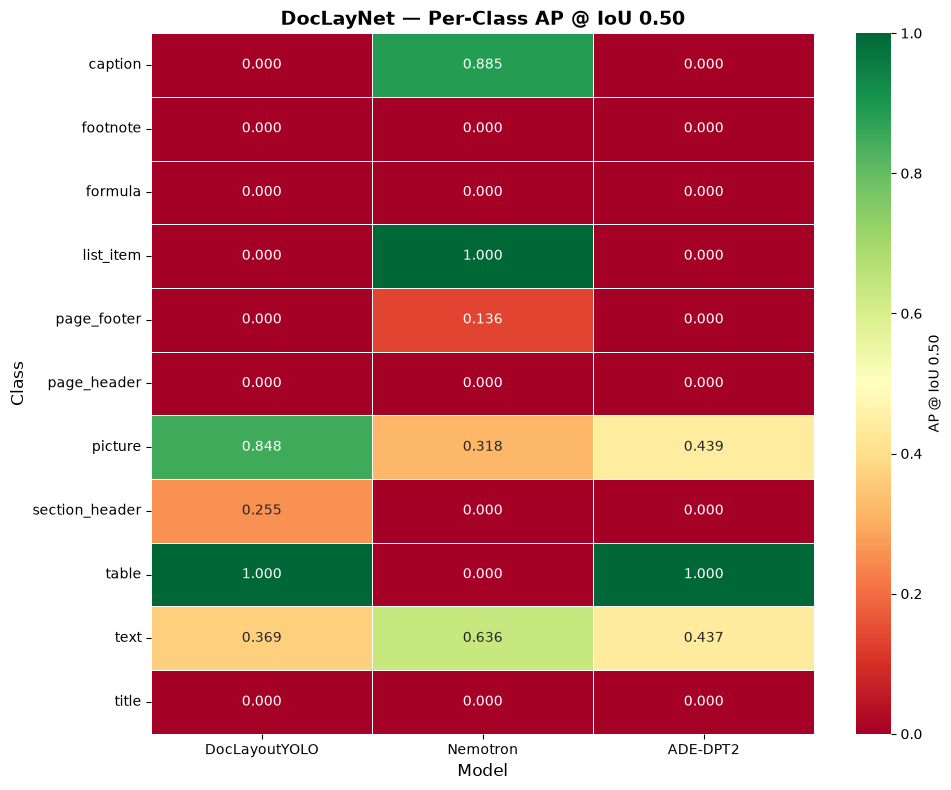

Saved per-class heatmap to /kaggle/working/benchmark_output/doclaynet_perclass_ap.png


In [11]:
# CELL 10: Per-class heatmap
import matplotlib.pyplot as plt
import seaborn as sns

classes = sorted(list(VALID_CLASSES_PER_DATASET['DocLayNet']))
models = ['DocLayoutYOLO', 'Nemotron', 'ADE-DPT2']

data = []
for c in classes:
    row = []
    for m in models:
        row.append(results['DocLayNet'][m]['ap50_per_class'].get(c, 0.0))
    data.append(row)

hm_df = pd.DataFrame(data, index=classes, columns=models)

plt.figure(figsize=(10, 8))
sns.heatmap(hm_df, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=.5, vmin=0, vmax=1,
            cbar_kws={'label': 'AP @ IoU 0.50'})
plt.title('DocLayNet — Per-Class AP @ IoU 0.50', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.tight_layout()

heatmap_path = f'{OUTPUT_DIR}/doclaynet_perclass_ap.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved per-class heatmap to {heatmap_path}")


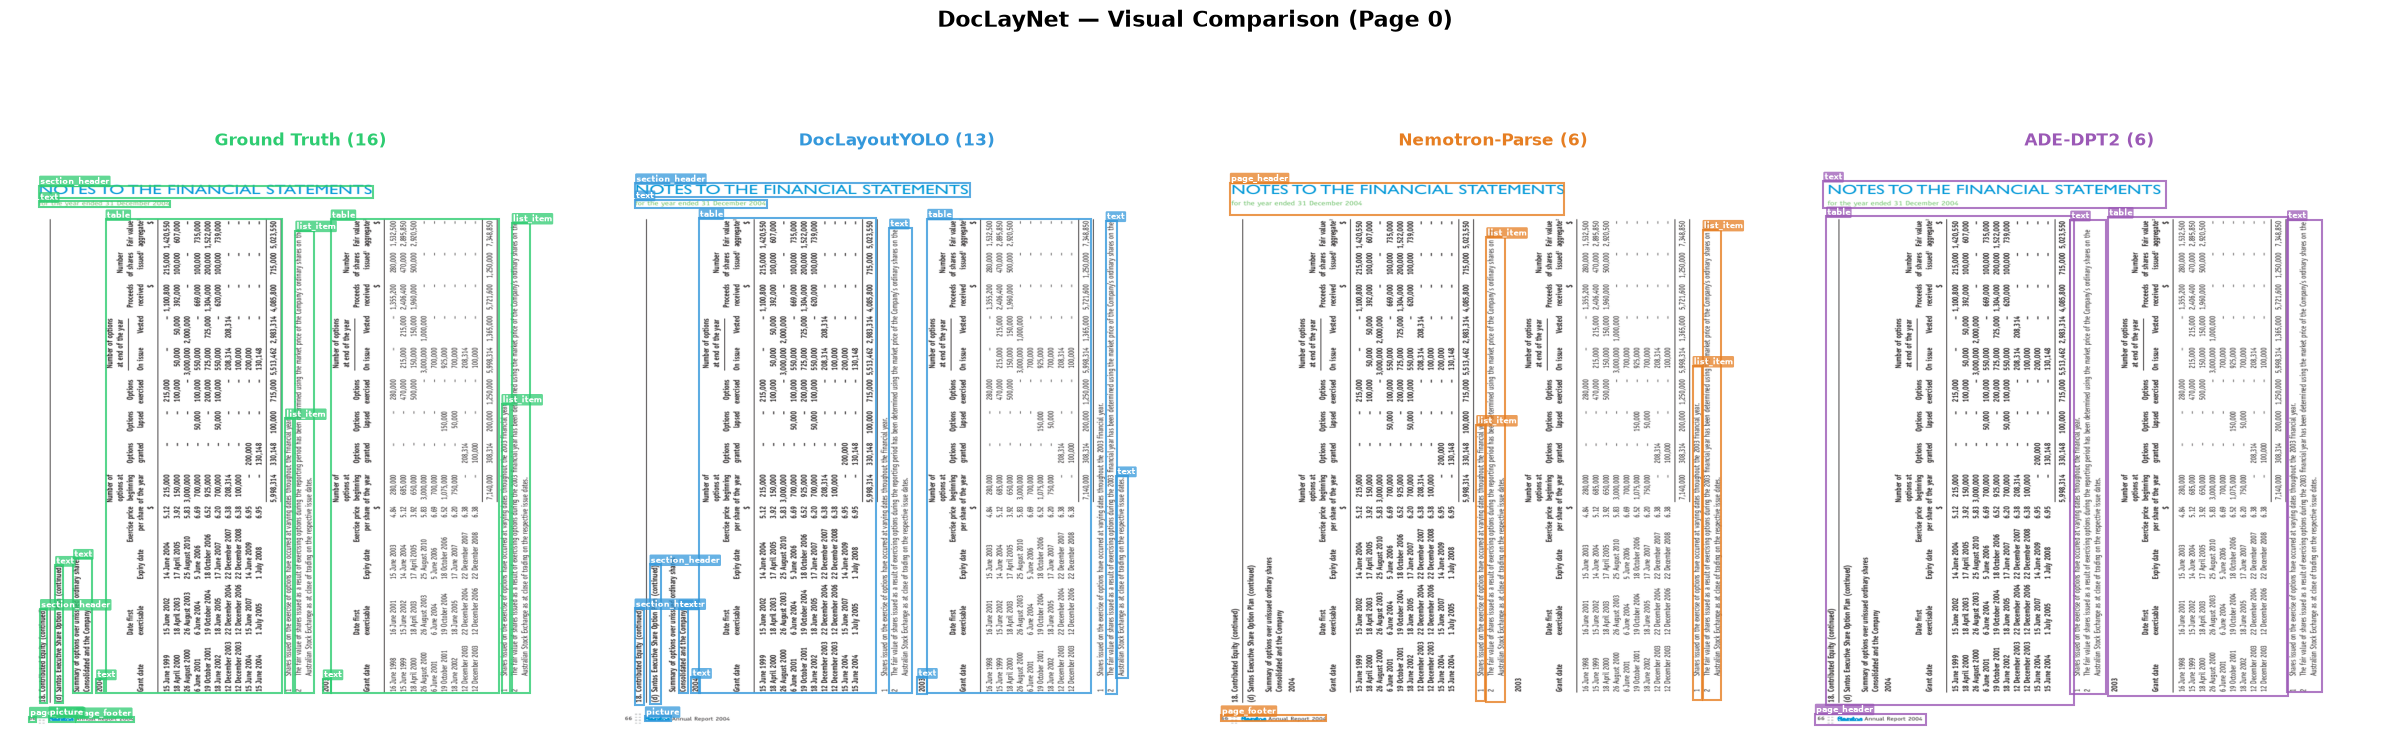

Saved visual sample to /kaggle/working/benchmark_output/visual_sample_DocLayNet.png


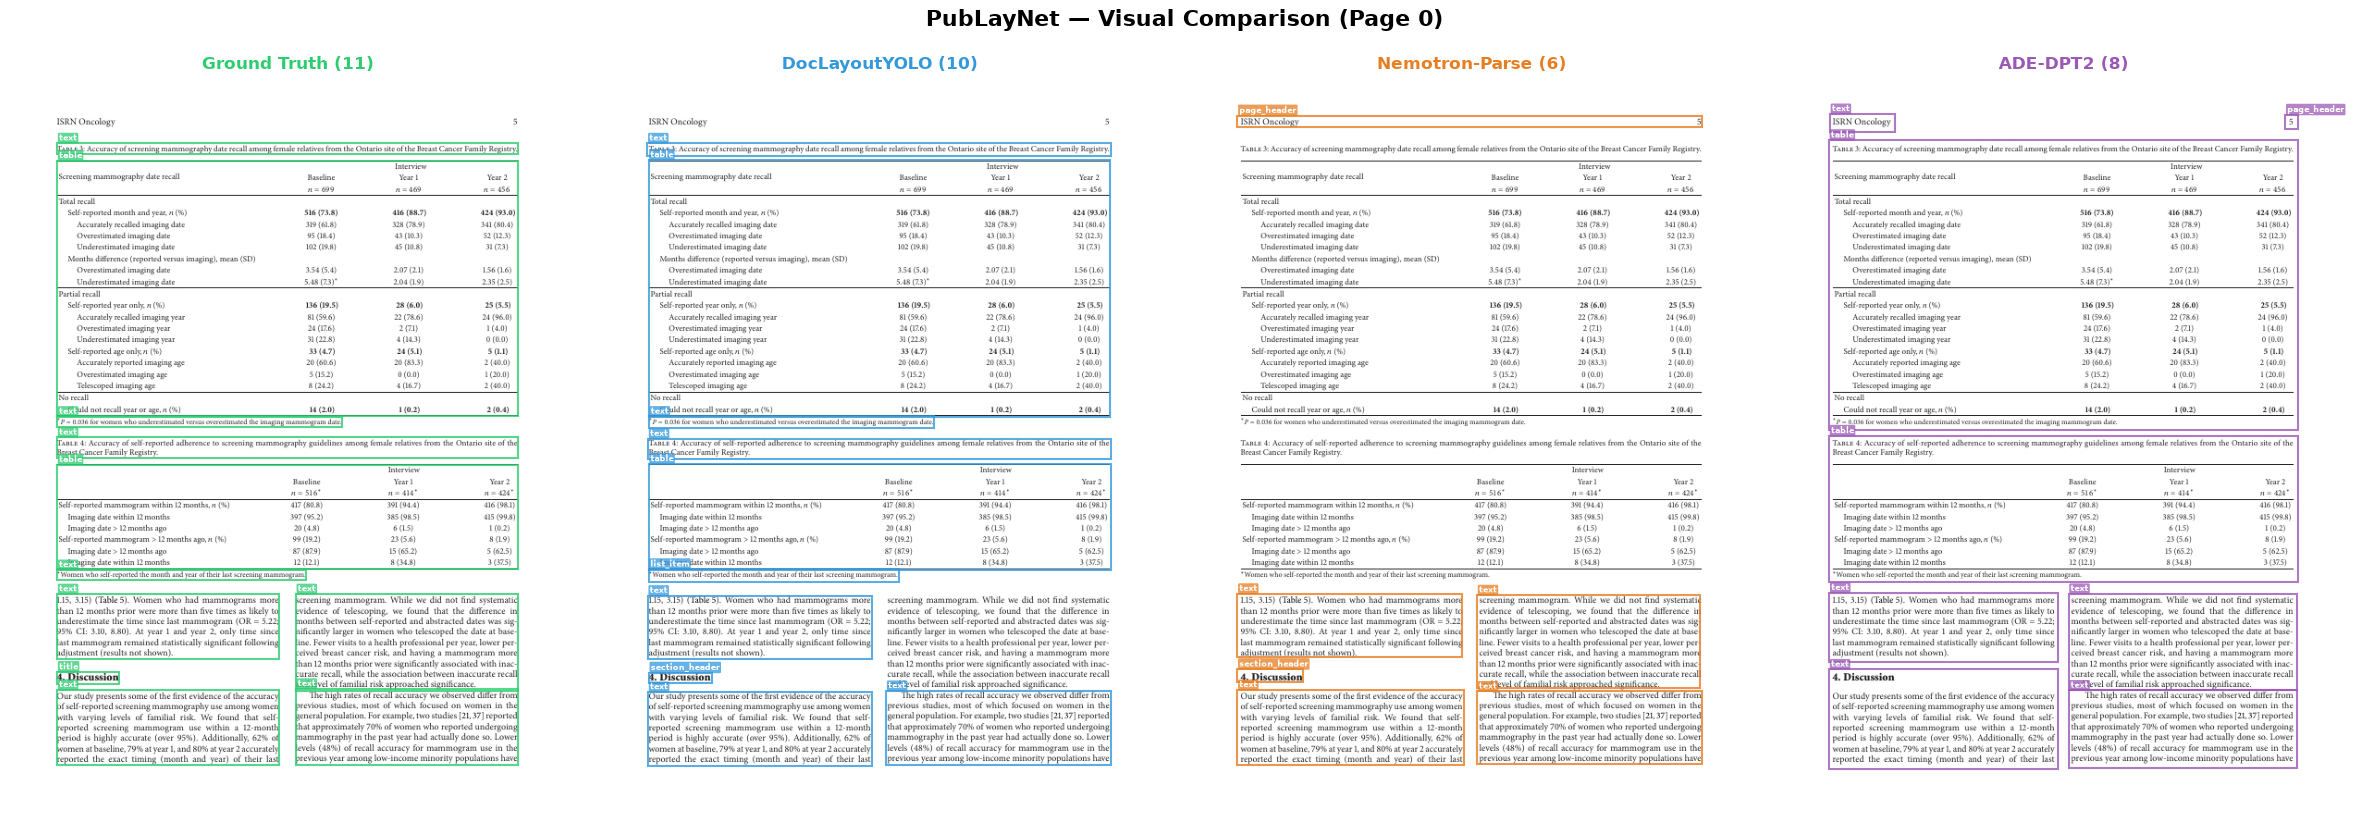

Saved visual sample to /kaggle/working/benchmark_output/visual_sample_PubLayNet.png


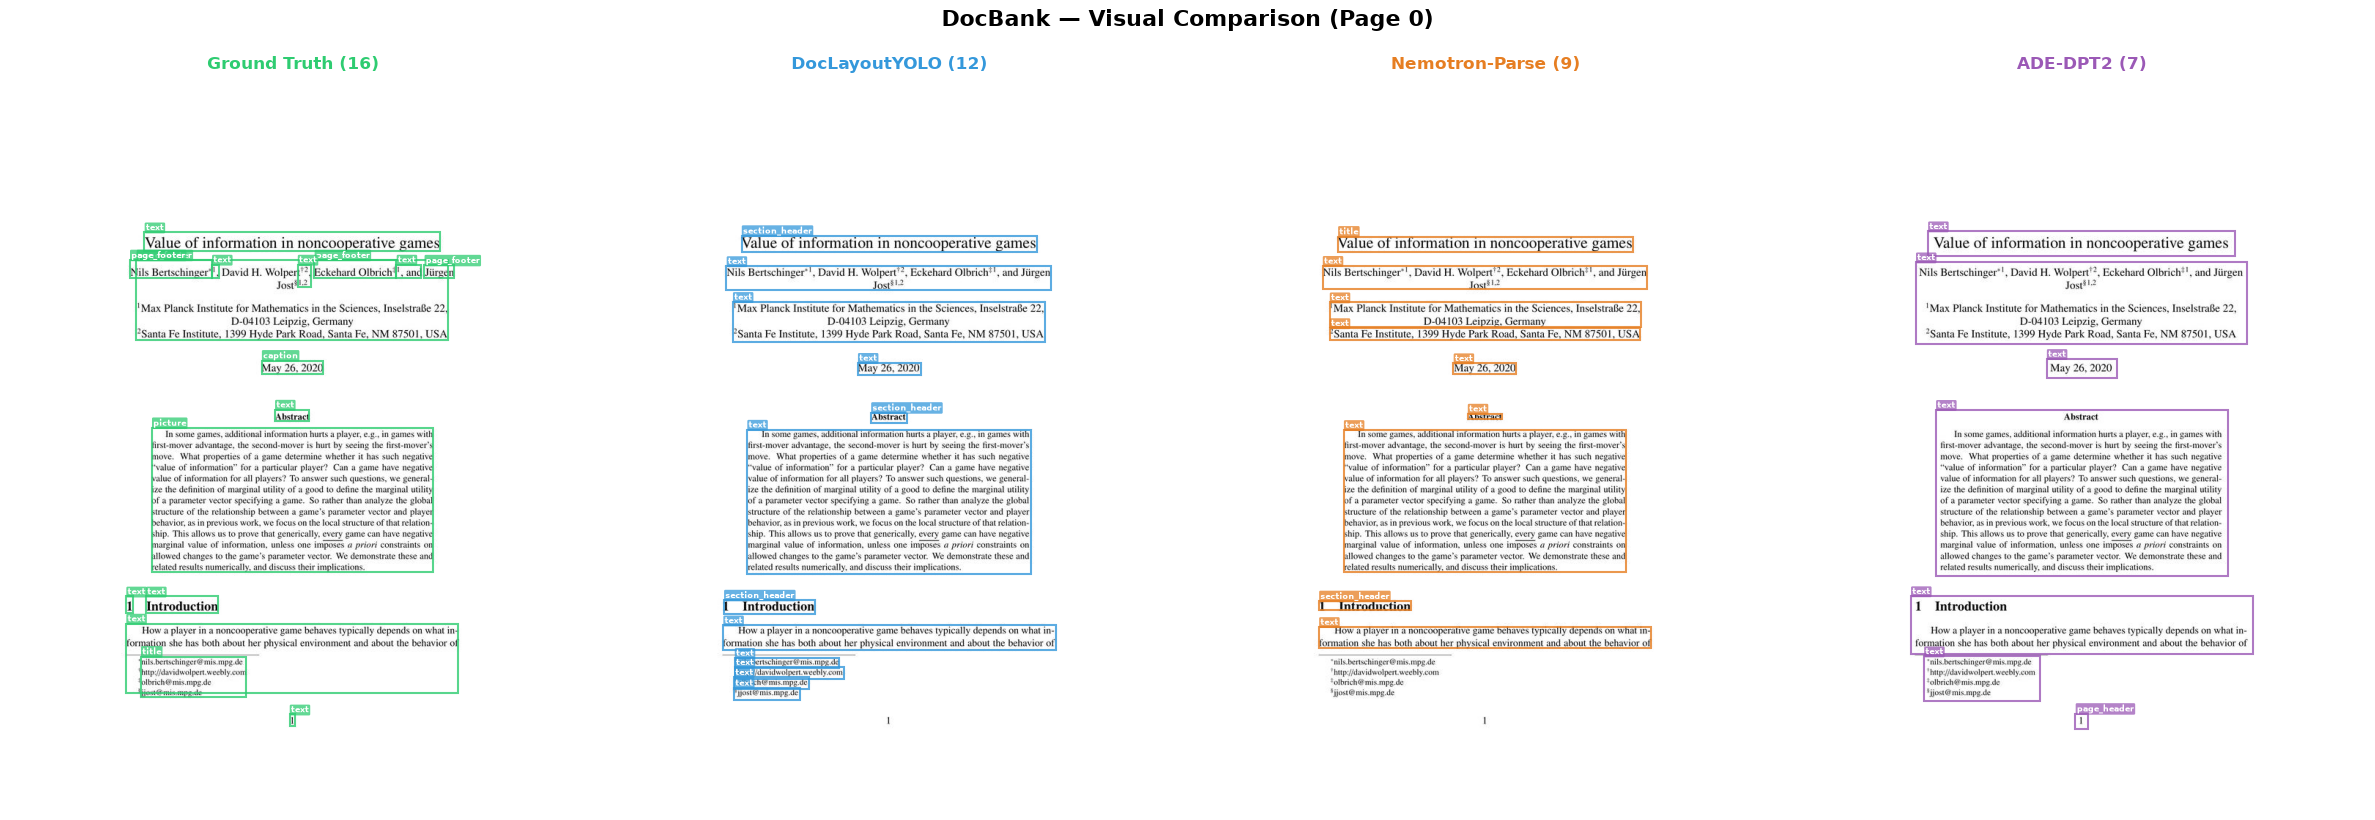

Saved visual sample to /kaggle/working/benchmark_output/visual_sample_DocBank.png


In [12]:
# CELL 11: Visual inspection sample
import matplotlib.patches as patches

MODEL_COLORS = {
    'GT': '#2ecc71',
    'DocLayoutYOLO': '#3498db',
    'Nemotron': '#e67e22',
    'ADE-DPT2': '#9b59b6',
}

for dataset_name in ['DocLayNet', 'PubLayNet', 'DocBank']:
    page_idx = 0
    sample = samples[dataset_name][page_idx]
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 8))
    fig.suptitle(f'{dataset_name} — Visual Comparison (Page {page_idx})', fontsize=16, fontweight='bold', y=1.02)
    
    def _draw(ax, img, boxes, color, title):
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight='bold', color=color)
        ax.axis('off')
        for b in boxes:
            x0, y0, x1, y1 = b['bbox']
            w, h = max(0, x1 - x0), max(0, y1 - y0)
            ax.add_patch(patches.Rectangle((x0, y0), w, h, linewidth=1.5, edgecolor=color, facecolor='none', alpha=0.8))
            ax.text(x0 + 2, y0 - 3, b['label'], fontsize=6, color='white', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor=color, alpha=0.75, edgecolor='none'))

    _draw(axes[0], sample['image'], sample['gt'], MODEL_COLORS['GT'], f'Ground Truth ({len(sample["gt"])})')
    
    # DocLayoutYOLO
    dl_boxes = dl_preds[dataset_name][page_idx]
    _draw(axes[1], sample['image'], dl_boxes, MODEL_COLORS['DocLayoutYOLO'], f'DocLayoutYOLO ({len(dl_boxes)})')
    
    # Nemotron
    nm_boxes = nm_preds[dataset_name][page_idx]
    _draw(axes[2], sample['image'], nm_boxes, MODEL_COLORS['Nemotron'], f'Nemotron-Parse ({len(nm_boxes)})')
    
    # ADE-DPT2
    ade_boxes = ade_preds[dataset_name][page_idx]
    _draw(axes[3], sample['image'], ade_boxes, MODEL_COLORS['ADE-DPT2'], f'ADE-DPT2 ({len(ade_boxes)})')
    
    plt.tight_layout()
    vis_path = f'{OUTPUT_DIR}/visual_sample_{dataset_name}.png'
    plt.savefig(vis_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved visual sample to {vis_path}")


In [13]:
# CELL 12: Save full results JSON
import json
json_path = f'{OUTPUT_DIR}/full_results.json'
with open(json_path, 'w') as f:
    json.dump(make_serializable(results), f, indent=2)
print(f'Full results saved to {json_path}')
print('Benchmark run complete!')


Full results saved to /kaggle/working/benchmark_output/full_results.json
Benchmark run complete!
